In [ ]:
# import general packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.colors as mcolors

colorWM = "#06948E"
colorPS = "#5C5D9E"

In [2]:
def mean_field(t, z, alpha, k, delta):
    """
    Parameters:
        t      : Time (required for ODE solvers)
        z      : List or array of concentrations [x1, x2, ..., xN]
        alpha  : Production rate of x1 (float)
        k      : List of production rate constants from x_{i-1} to x_i, length N-1
        delta  : List of degradation rate constants, length N
    Returns:
        dzdt   : List of time derivatives [dx1/dt, dx2/dt, ..., dxN/dt]
    """
    N = len(z)
    dzdt = [0.0] * N

    # x1 dynamics
    dzdt[0] = alpha - delta[0] * z[0] * z[-1]  # z[-1] is xN

    # x_i dynamics for i = 2 to N
    for i in range(1, N):
        dzdt[i] = k[i-1] * z[i-1] - delta[i] * z[i]

    return dzdt

def mean_field_phasesep(t, z, alpha, k, delta):
    """
    Parameters:
        t      : Time (required for ODE solvers)
        z      : List or array of concentrations [x1, x2, ..., xN]
        alpha  : Production rate of x1 (float)
        k      : List of production rate constants from x_{i-1} to x_i, length N-1
        delta  : List of degradation rate constants, length N
    Returns:
        dzdt   : List of time derivatives [dx1/dt, dx2/dt, ..., dxN/dt]
    """
    N = len(z)
    dzdt = [0.0] * N

    # x1 dynamics
    dzdt[0] = alpha - delta[0] * z[0]**(1/3) * z[-1]  # z[-1] is xN

    # x_i dynamics for i = 2 to N
    for i in range(1, N):
        dzdt[i] = k[i-1] * z[i-1] - delta[i] * z[i]

    return dzdt

def get_cartesian_style_axis(ax):
    # Hide top, right, left spines (borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Hide y-axis and y-ticks
    ax.yaxis.set_visible(True)

    # Only keep the bottom spine (x-axis)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    # Only show x-ticks
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

def get_n_colors(n):
    base_colors = ["tab:blue", "tab:orange", "tab:red", "tab:green"]
    if n <= len(base_colors):
        return base_colors[:n]
    else:
        cmap = plt.get_cmap("tab20")  # or 'hsv', 'nipy_spectral' for more variety
        extra_colors = [cmap(i / (n - len(base_colors))) for i in range(n - len(base_colors))]
        # Convert RGBA to hex or keep as RGBA
        extra_colors = [mcolors.to_hex(c) for c in extra_colors]
        return base_colors + extra_colors

# Well-mixed ODE

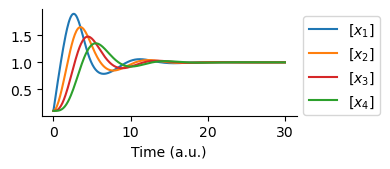

In [3]:
N = 4
pref = 1

alpha = pref
k = pref*np.ones((N-1))         # len = N-1
delta = pref*np.ones((N))   # len = N

z0 = [0.1] * N
tspan = (0, 30)
sol_mean_field = solve_ivp(lambda t, z: mean_field(t, z, alpha, k, delta), tspan, z0, max_step=0.1)

# Example
colors = get_n_colors(N)

plt.figure(figsize=(4,1.8))
for i in range(N):
    plt.plot(sol_mean_field.t, sol_mean_field.y[i], color = colors[i], label = r"$[x_"+str(i+1)+"]$")
plt.legend(bbox_to_anchor=(1.0, 1),
                         loc='upper left')
plt.xlabel("Time (a.u.)")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/WM_damped.svg")

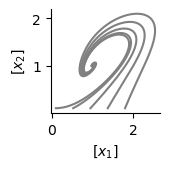

In [4]:
plt.figure(figsize=(1.8,1.8))
for x10 in np.linspace(0.1,1.8,5):
        z0[0] = x10
        tspan = (0, 30)
        sol_mean_field = solve_ivp(lambda t, z: mean_field(t, z, alpha, k, delta), tspan, z0, max_step=0.1)

        plt.plot(sol_mean_field.y[0], sol_mean_field.y[1], color = "gray")

ax = plt.gca()
get_cartesian_style_axis(ax)
plt.xlabel(r"$[x_1]$")
plt.ylabel(r"$[x_2]$")
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/wave.svg")

# Phase-sep ODE

## N>5

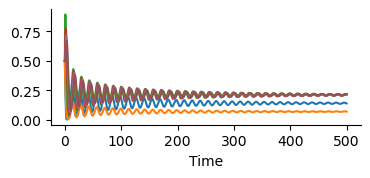

In [5]:
N = 6
alpha = 1/9
k = 1*np.ones((N-1))         # len = N-1
k[0] = 0.5
k[1] =  3
delta = 1*np.ones((N))   # len = N

z0 = [0.5] * N
tspan = (0, 500)
sol_mean_field = solve_ivp(lambda t, z: mean_field_phasesep(t, z, alpha, k, delta), tspan, z0, max_step=0.1)

colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:purple", "tab:brown"]

plt.figure(figsize=(4,1.5))
for i in range(N):
    plt.plot(sol_mean_field.t, sol_mean_field.y[i])#, color = colors[i], label = r"$[x_"+str(i+1)+"]$")
#plt.legend(bbox_to_anchor=(1.0, 1),
#                         loc='upper left')
plt.xlabel("Time")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.show()

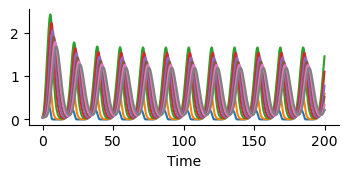

In [6]:
N = 8
alpha = 1/9
k = 1*np.ones((N-1))         # len = N-1
k[0] = k[1] =  3
delta = 1*np.ones((N))   # len = N

z0 = [0.05] * N
tspan = (0, 200)
sol_mean_field = solve_ivp(lambda t, z: mean_field_phasesep(t, z, alpha, k, delta), tspan, z0, max_step=0.1)

colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:purple", "tab:brown"]

plt.figure(figsize=(4,1.5))
for i in range(N):
    plt.plot(sol_mean_field.t, sol_mean_field.y[i])#, color = colors[i], label = r"$[x_"+str(i+1)+"]$")
#plt.legend(bbox_to_anchor=(1.0, 1),
#                         loc='upper left')
plt.xlabel("Time")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.show()

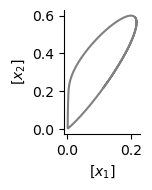

In [7]:
i = 0
plt.figure(figsize=(1.6,2))
plt.plot(sol_mean_field.y[i][-200:], sol_mean_field.y[i+1][-200:], color = "gray")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.xlabel(r"$[x_1]$")
plt.ylabel(r"$[x_2]$")
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/limit_cycle_PS.svg")

## N<5

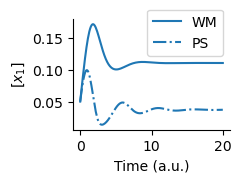

In [8]:
N = 3
alpha = 1/9
k = np.ones((N-1))         # len = N-1
k[0] = 3
k[1]= 3
delta = np.ones((N))   # len = N

z0 = [0.05] * N
tspan = (0, 20)
sol_mean_fieldPS = solve_ivp(lambda t, z: mean_field_phasesep(t, z, alpha, k, delta), tspan, z0, max_step=0.1)
sol_mean_fieldWM = solve_ivp(lambda t, z: mean_field(t, z, alpha, k, delta), tspan, z0, max_step=0.1)

colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:purple", "tab:brown"]
plt.figure(figsize=(2.5,2))
for i in range(1):
    plt.plot(sol_mean_fieldWM.t, sol_mean_fieldWM.y[i], color ="tab:blue", label = "WM")
    plt.plot(sol_mean_fieldPS.t, sol_mean_fieldPS.y[i], color = "tab:blue", linestyle = "-.", label = "PS")#, color = colors[i], label = r"$[x_"+str(i+1)+"]$")

plt.legend(bbox_to_anchor=(1.0, 1.15),
                         loc='upper right')
plt.xlabel("Time (a.u.)")
plt.ylabel(r"$[x_1]$")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/WM_vs_PS.svg")

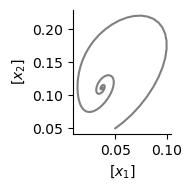

In [9]:
plt.figure(figsize=(2,2))
plt.plot(sol_mean_fieldPS.y[0][:], sol_mean_fieldPS.y[1][:], color = "gray")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.xlabel(r"$[x_1]$")
plt.ylabel(r"$[x_2]$")
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/spiral.svg")

# Plot Re(lambda) as function of N nodes from analytical formula

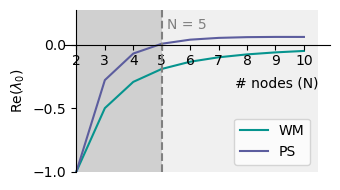

In [10]:
num_states = np.arange(2, 11)

a_1 = 1/9
real_part_lambda = a_1 ** (-1 / (2 * num_states)) * np.cos(np.pi / num_states) - 1
re_lambda_WM = np.cos(np.pi/num_states) -1
im_lambda_WM = np.sin(np.pi/num_states)

re_lambda_PS = 9**(1/(2*num_states))*np.cos(np.pi/num_states) -1
im_lambda_PS = 9**(1/(2*num_states))*np.sin(np.pi/num_states)

plt.figure(figsize=(3.5, 2))
ax = plt.gca()

# Add background colors
ax.axvspan(2, 5, facecolor="#d0d0d0", zorder=0)
ax.axvspan(5, 10.5, facecolor='#f0f0f0', zorder=0)

# Plot the curve
ax.plot(num_states, re_lambda_WM, color=colorWM, zorder=0, label = "WM")
ax.plot(num_states, re_lambda_PS, color=colorPS, zorder=1, label = "PS")

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis at y = 0
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 2))
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# Adjust y-limits to show a bit more positive space
ymin, ymax = re_lambda_PS.min(), re_lambda_PS.max()
ax.set_ylim(ymin, ymax + 0.2 * (ymax - ymin))

# Add vertical dashed line at x = 5
ax.axvline(x=5, ymin=0, ymax=1, color='gray', linestyle='--', zorder=2)
ax.text(5.2, 0.1, 'N = 5', ha='left', va='bottom', color='gray')

# Set xticks at all integers 1 through 10
ax.set_xticks(num_states)

# Set xlabel manually at bottom right
ax.text(num_states[-1] + 0.5, -0.25, "# nodes (N)", ha='right', va='top')

# Y-axis label
ax.set_ylabel(r"$\mathrm{Re}(\lambda_0)$")
plt.legend(bbox_to_anchor=(0.95, 0),
                         loc='lower right')
plt.tight_layout()

plt.savefig("./neg_feedback_loop_paper_figures/re_lambda.svg")

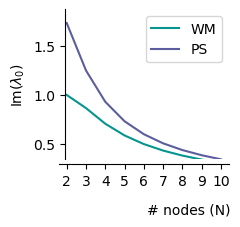

In [12]:
num_states = np.arange(2, 11)
a_1 = 1/9
real_part_lambda = a_1 ** (-1 / (2 * num_states)) * np.cos(np.pi / num_states) - 1
re_lambda_WM = np.cos(np.pi/num_states) -1
im_lambda_WM = np.sin(np.pi/num_states)

re_lambda_PS = 9**(1/(2*num_states))*np.cos(np.pi/num_states) -1
im_lambda_PS = 9**(1/(2*num_states))*np.sin(np.pi/num_states)

plt.figure(figsize=(2.5, 2.5))
ax = plt.gca()

# Plot the curve
ax.plot(num_states, im_lambda_WM, color=colorWM, zorder=0, label = "WM")
ax.plot(num_states, im_lambda_PS, color=colorPS, zorder=1, label = "PS")

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis at y = 0
ax.spines['bottom'].set_position(('data', ymin-0.05))
ax.spines['left'].set_position(('data', 2-0.1))
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# Adjust y-limits to show a bit more positive space
ymin, ymax = im_lambda_PS.min(), im_lambda_PS.max()
ax.set_ylim(ymin, ymax + 0.1 * (ymax - ymin))

# Set xticks at all integers 1 through 10
ax.set_xticks(num_states)

# Set xlabel manually at bottom right
ax.text(num_states[-1] + 0.5, -0.1, "# nodes (N)", ha='right', va='top')

# Y-axis label
ax.set_ylabel(r"$\mathrm{Im}(\lambda_0)$")
plt.legend()
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/im_lambda.svg")